In [5]:
import os
import sys
from collections import Counter
# Add project path
notebook_path = os.getcwd()
sys.path.insert(0, os.path.dirname(notebook_path))

# current_file = os.path.abspath(__file__)
# grandparent_dir = os.path.dirname(os.path.dirname(current_file))
# sys.path.insert(0, grandparent_dir)
%matplotlib inline
import torch
import torch.nn.functional as F
from torch.nn import Linear
from torch_geometric.nn import GCNConv
from torch_geometric.utils import from_networkx, negative_sampling
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import pandas as pd
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import k_hop_subgraph, to_networkx
from torch_geometric.data import Data
from syn_real.syn_datagen import analyze_automorphisms

In [6]:
def build_graph(dataset_name="Cora", 
                num_hops=3, 
                node_idx=0, 
                visualize=True,
                analyze=True):
    """
    Load a dataset and extract a k-hop subgraph around a given node.

    Args:
        dataset_name (str): e.g. "Cora", "Citeseer", "PubMed"
        num_hops (int): Number of hops to include in the subgraph
        node_idx (int): Center node to extract from
        visualize (bool): If True, visualize the subgraph

    Returns:
        Data: PyG Data object of the subgraph
    """
    # Load dataset

    dataset = Planetoid(root=f'{dataset_name}', name=dataset_name)
    data = dataset[0]

    # Extract k-hop subgraph
    subset, sub_edge_index, mapping, edge_mask = k_hop_subgraph(
        node_idx=node_idx,
        num_hops=num_hops,
        edge_index=data.edge_index,
        relabel_nodes=True,
        num_nodes=data.num_nodes
    )

    # Create subgraph Data object
    sub_x = data.x[subset]
    sub_x = torch.ones_like(sub_x)
    sub_y = data.y[subset]
    sub_data = Data(x=sub_x, edge_index=sub_edge_index, y=sub_y)

    subG_data = to_networkx(sub_data, to_undirected=True)
    
    for n in subG_data.nodes():
        subG_data.nodes[n]['x'] = [1.0]
    if True:
        num_automorphic_edges, num_non_automorphic_edges, non_automorphic_edges, automorphic_edges = analyze_automorphisms(sub_data, subG_data) # classify edges to be automorphic or not

    if visualize:
        plt.figure(figsize=(8, 6))
        nx.draw(subG_data, with_labels=True, node_size=300, 
                node_color='skyblue', edge_color='gray')
        plt.title(f"{num_hops}-Hop Subgraph from Node {node_idx} ({dataset_name})")
        plt.axis('off')
        plt.show()
    print("Num nodes:", data.num_nodes)
    print("Num edges:", data.edge_index.size(1))
    return sub_data, automorphic_edges, subG_data

In [7]:
class GCN(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        return self.conv2(x, edge_index)

class LinkPredictor(torch.nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.lin = Linear(2 * dim, 1)

    def forward(self, x_i, x_j):
        return torch.sigmoid(self.lin(torch.cat([x_i, x_j], dim=-1))).squeeze(-1)

unique orbit node: 19
Intra-orbit edges: 1725, Inter-orbit edges: 4314
Automorphic edges: 6039
Distinguishable edges: 361


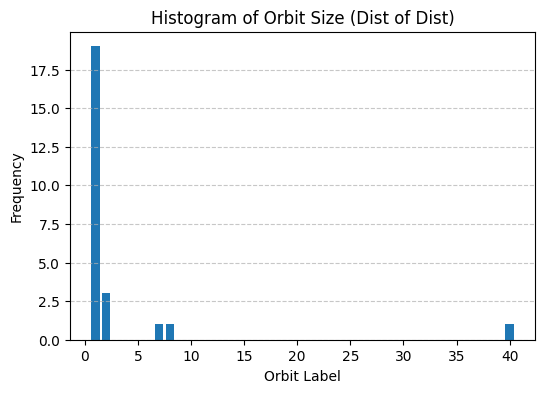

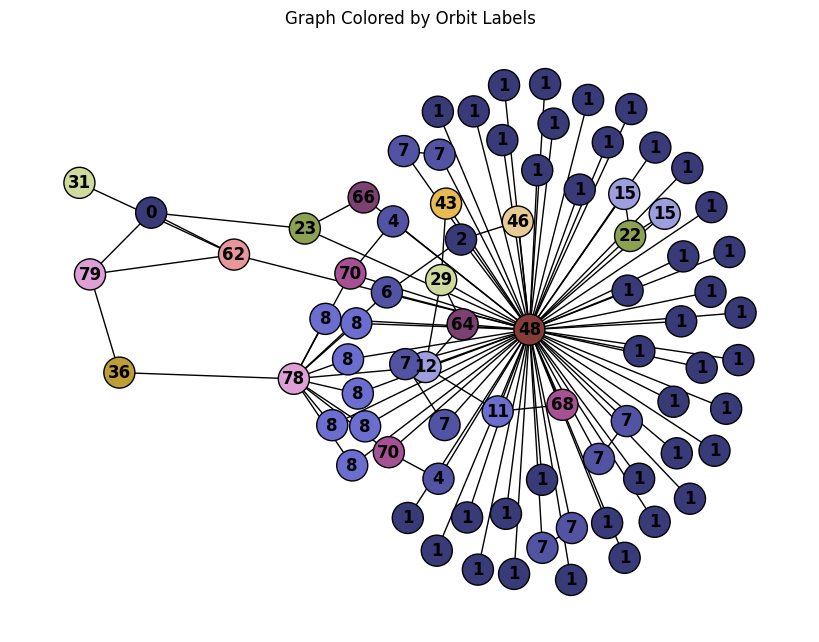

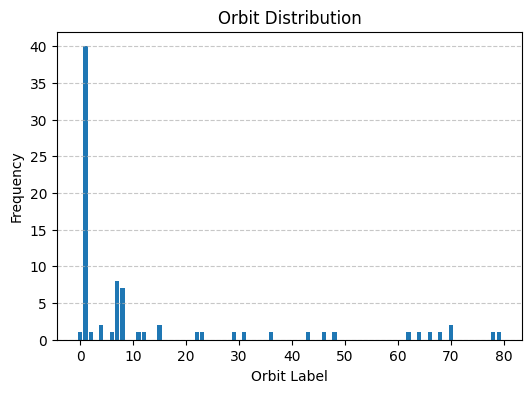

Edge class counts: [40, 8, 7, 7, 4, 2, 2, 2, 2, 2]
Unique Edge classes: 42


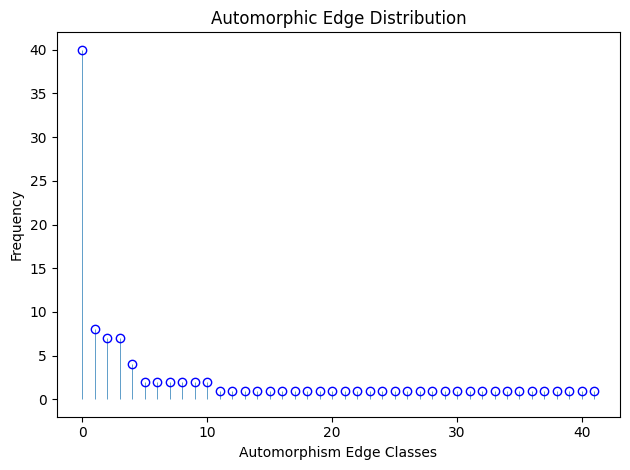

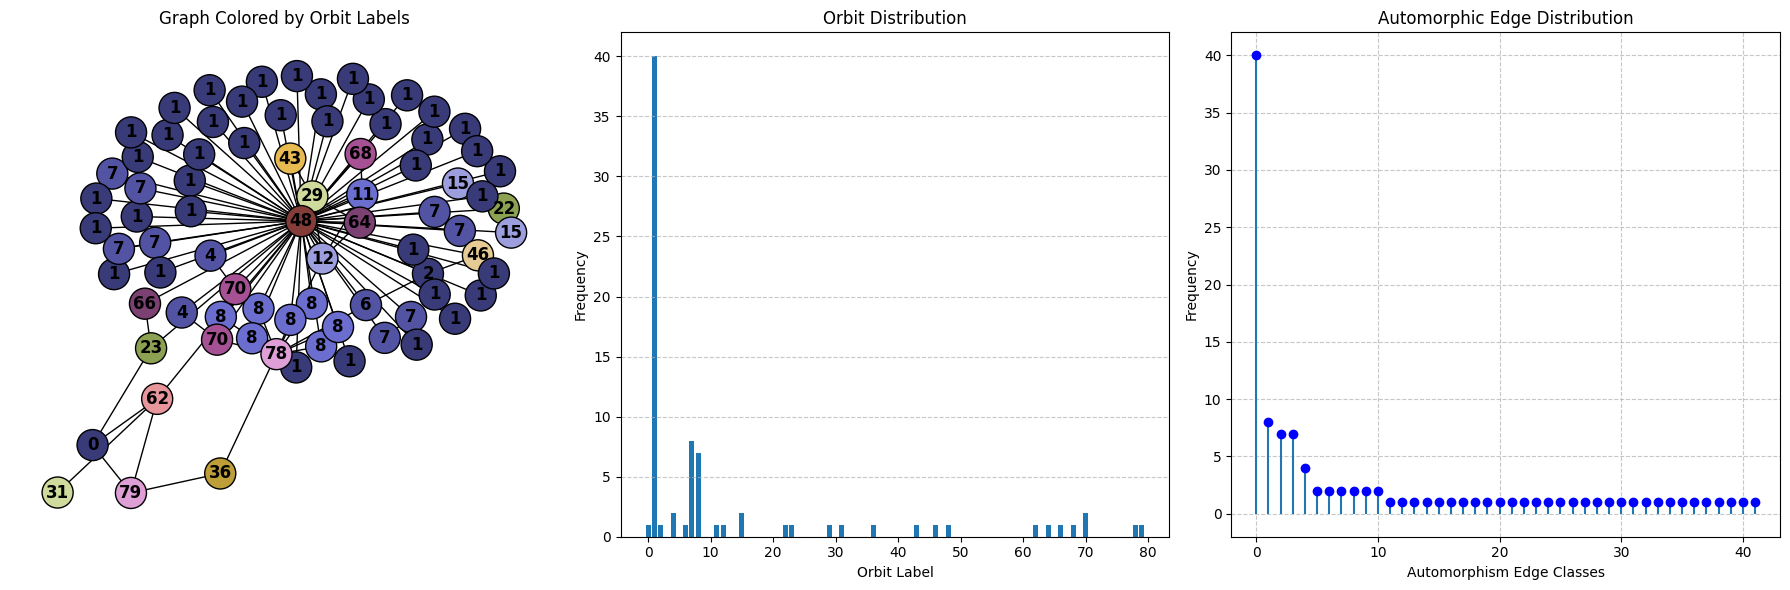

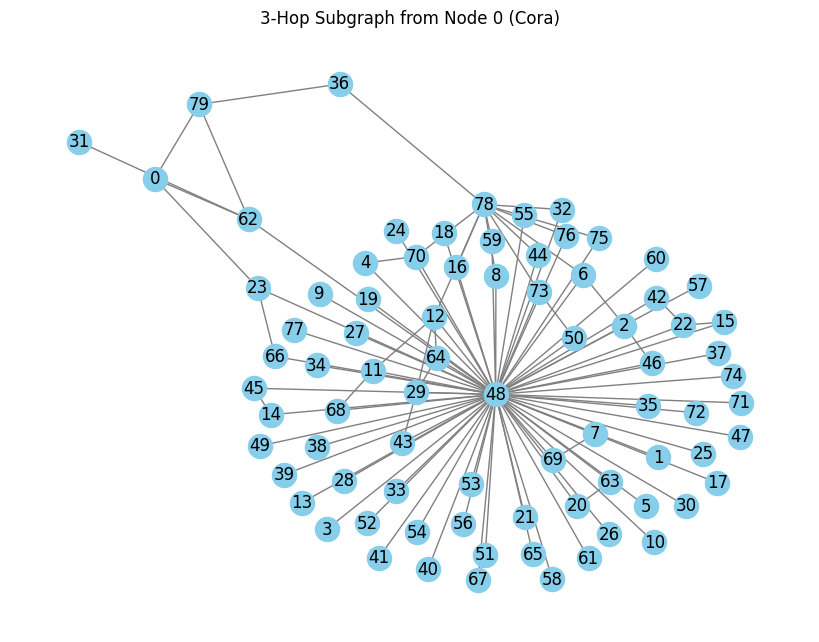

Num nodes: 2708
Num edges: 10556


ValueError: not enough values to unpack (expected 4, got 3)

In [8]:
def run():
    data, auto_edges, auto_nodes, G_nx = build_graph()
    edge_index = data.edge_index
    data.x = torch.tensor([d['x'] for _, d in G_nx.nodes(data=True)], dtype=torch.float)

    model = GCN(1, 16)
    predictor = LinkPredictor(16)
    optimizer = torch.optim.Adam(list(model.parameters()) + list(predictor.parameters()), lr=0.01)

    neg_edge_index = negative_sampling(edge_index, data.num_nodes, edge_index.size(1))
    all_edge_index = torch.cat([edge_index, neg_edge_index], dim=1)
    labels = torch.cat([torch.ones(edge_index.size(1)), torch.zeros(neg_edge_index.size(1))])

    for _ in range(100):
        model.train()
        x = model(data.x, edge_index)
        src, dst = all_edge_index
        pred = predictor(x[src], x[dst])
        loss = F.binary_cross_entropy(pred, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    model.eval()
    x = model(data.x, edge_index).detach()

    tsne = TSNE(n_components=2, perplexity=2,random_state=0)
    x_2d = tsne.fit_transform(x.numpy())

    # Plot node embeddings
    plt.figure(figsize=(8,6))
    for i, (x_, y_) in enumerate(x_2d):
        color = 'red' if i in auto_nodes else 'blue'
        plt.scatter(x_, y_, c=color)
        plt.text(x_ + 0.02, y_ + 0.02, str(i), fontsize=9)
    plt.title("2D Visualization of Node Embeddings")
    plt.show()
    
    
    preds, types = [], []
    for i in range(all_edge_index.shape[1]):
        s, d = int(all_edge_index[0, i]), int(all_edge_index[1, i])
        pred = predictor(x[s].unsqueeze(0), x[d].unsqueeze(0)).item()
        t = 'A' if (s,d) in auto_edges or (d,s) in auto_edges else 'NA'
        preds.append(pred)
        types.append(t)

    df = pd.DataFrame({"Prediction": preds, "EdgeType": types})
    df.boxplot(column="Prediction", by="EdgeType")
    plt.title("Link Prediction Score by Edge Type")
    plt.suptitle("")
    plt.ylabel("Score")
    plt.show()

run()